# Life as a Dynamical Attractor

This notebook explores a minimal dynamical system representing activity in a prebiotic chemical network. The model investigates whether activity collapses to zero or persists as a stable attractor depending on environmental conditions and nonlinear feedback dynamics.

The behavior of the system is controlled primarily by three factors:

• environmental input $I$  
• degradation rate $\delta$  
• feedback strength $\alpha$

These parameters determine whether chemical activity disappears or becomes self-sustaining.

We analyze the system through several dynamical perspectives:

1. Time evolution of activity  
2. Persistence versus collapse  
3. Parameter-dependent regime maps  
4. Basin of attraction and robustness  
5. Recovery from perturbations  
6. Extension to chirality and symmetry breaking

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import plotly.graph_objects as go

plt.style.use("seaborn-v0_8")

## Model Equation

We model the activity variable $x(t)$ using the nonlinear differential equation

$$
\frac{dx}{dt} = \alpha \frac{x^n}{K^n + x^n}\left(1 - \frac{x}{K_c}\right) - \delta x + I
$$

where:

• $x$ — activity level of the chemical network  
• $\alpha$ — feedback strength  
• $n$ — Hill coefficient controlling the steepness of the nonlinear feedback response
• $K$ — saturation constant for the feedback term  
• $K_c$ — carrying capacity representing resource limitation  
• $\delta$ — degradation rate  
• $I$ — environmental input

The equation combines several competing processes:

1. **Autocatalytic growth** proportional to the current activity level $x$  
2. Nonlinear positive feedback described by a Hill function, which allows sharp activation once activity exceeds a characteristic threshold.
3. **Resource limitation** represented by the logistic saturation term $(1 - x/K_c)$  
4. **Loss and environmental forcing** through degradation ($\delta x$) and external input ($I$)

Together these mechanisms determine whether activity collapses to zero or persists as a stable dynamical attractor.

This minimal dynamical system allows us to investigate when sustained activity can emerge and remain stable under environmental fluctuations.

In [2]:
def model(t, x, alpha, n, K, Kc, delta, I):

    x = max(x[0], 0)

    hill = x**n / (K**n + x**n)

    growth = alpha * x * hill * (1 - x/Kc)
    loss = delta * x

    dxdt = growth - loss + I

    return [dxdt]

In [3]:
def simulate(x0, alpha, n, K, Kc, delta, I, t=300, num_points=1000):

    t_span = (0, t)
    t_eval = np.linspace(0, t, num_points)

    sol = solve_ivp(
        model,
        t_span,
        [x0],
        args=(alpha, n, K, Kc, delta, I),
        t_eval=t_eval
    )

    if not sol.success:
        return None, None

    return sol.t, sol.y[0]

In [4]:
def final_state(x0, alpha, n, K, Kc, delta, I, t=300):

    t_span = (0, t)

    sol = solve_ivp(
        model,
        t_span,
        [x0],
        args=(alpha, n, K, Kc, delta, I)
    )

    if not sol.success:
        return np.nan

    return sol.y[0][-1]

## Baseline Parameters

The parameter values are chosen to place the system in a regime where
positive feedback, degradation, and environmental input are of comparable
magnitude. This allows the model to exhibit threshold behavior between
collapse and persistence, which is necessary to study life-like dynamical
attractors.

- **α (feedback strength)** controls the intensity of autocatalytic growth.
  Moderate values (α ≈ 2) allow feedback to compete with degradation.

- **n (Hill coefficient)** determines the steepness of the feedback response.
  Values $n \ge 2$ generate switch-like threshold behavior typical of cooperative
  or autocatalytic systems.

- **K (activation constant)** sets the activity scale where nonlinear feedback
  begins to activate. We normalize it to $K = 1$ so that activity levels are
  measured relative to the feedback threshold.

- **$K_c$ (capacity scale)** limits total activity through the saturation factor
  $1 - x/K_c$. This represents finite environmental resources that prevent
  unbounded growth. We set $K_c = 20$ so that saturation occurs well above
  the activity levels where bistability emerges.

- **δ (degradation rate)** represents loss or dilution of activity.

- **I (environmental input)** represents background energy or material influx.

- **$x_0$ (initial condition)** is the initial seed of activity used to test
  whether the system can grow from small fluctuations.

These values are not intended to represent a specific chemical system;
instead they create a dynamical regime suitable for exploring persistence,
collapse, and attractor behavior.

In [5]:
alpha = 2.0
n = 3 #(moderately strong nonlinear feedback)
K = 1.0
Kc = 20
delta = 0.5
I = 0.2
x0 = 0.1

epsilon = 1e-3

## Time Series Simulation

We first simulate the system for a single set of parameters to observe whether activity collapses or converges to a stable non-zero steady state.

This provides the most direct view of the dynamical attractor.

In [6]:
t, x_t = simulate(x0, alpha, n, K, Kc, delta, I, t=300, num_points=1000)

if t is None:
    raise RuntimeError("Simulation failed — parameters may cause instability")

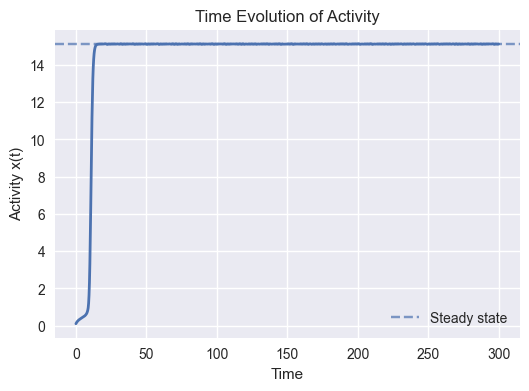

In [7]:
plt.figure(figsize=(6,4))

plt.plot(t, x_t, linewidth=2)

# show steady-state level
plt.axhline(x_t[-1], linestyle="--", alpha=0.7, label="Steady state")

plt.xlabel("Time")
plt.ylabel("Activity x(t)")
plt.title("Time Evolution of Activity")

plt.grid(True)
plt.legend()

plt.show()

**Interpretation of the Time Evolution of Activity**

This simulation shows how the activity level $x(t)$ evolves over time starting from a small initial seed of activity.

The activity initially increases due to the combined effects of nonlinear feedback and environmental input. As activity grows, the effective growth slows and the system approaches a constant value.

This plateau indicates that the system reaches a **stable non-zero steady state**, where the net rate of change becomes approximately zero:

$$
\frac{dx}{dt} \approx 0
$$

At this point, feedback, degradation, and environmental support balance one another.

This result shows that the model can sustain persistent activity from a small fluctuation, and that the long-term state acts as a **stable dynamical attractor**.

## Persistence Classification

We classify the outcome based on the final activity value.

- **Persistent regime**: final activity remains above a small threshold
- **Collapse regime**: final activity decays toward zero

In [8]:
if x_t[-1] > epsilon:
    print("Persistent regime")
else:
    print("Collapse regime")

Persistent regime


## Effect of Feedback Strength

The parameter α controls the strength of the nonlinear positive feedback in the system.

If α is small, feedback is weak and activity may decay toward zero.
If α is large, feedback amplification becomes strong and sustained activity becomes more likely.

To understand this effect, we simulate the system for several different values of α while keeping all other parameters fixed.

This allows us to observe how the strength of feedback changes the long-term behavior of the system.

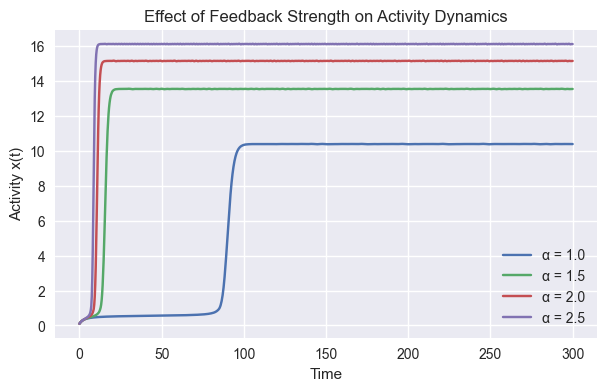

In [9]:
alpha_values = [1.0, 1.5, 2.0, 2.5]

plt.figure(figsize=(7,4))

for a in alpha_values:
    t, x_series = simulate(x0, a, n, K, Kc, delta, I)
    plt.plot(t, x_series, label=f"α = {a}")

plt.xlabel("Time")
plt.ylabel("Activity x(t)")
plt.title("Effect of Feedback Strength on Activity Dynamics")

plt.legend()
plt.grid(True)
plt.show()

**Interpretation of Effect of Feedback Strength on Activity Dynamics**

As the feedback strength \(\alpha\) increases, the system converges to higher steady-state activity levels.

Stronger feedback increases the effective self-amplification of activity, allowing the system to settle at a larger persistent state.

The trajectories also show that larger values of \(\alpha\) lead to faster convergence toward the plateau.

This indicates that feedback strength strongly influences both:

- the **magnitude** of sustained activity
- the **rate** at which the system approaches its attractor

## Steady-State Activity as a Function of Feedback Strength

To quantify the effect of feedback strength more systematically, we scan α across a range of values and record the steady-state activity reached by the system.

This produces a curve showing how the attractor level depends on the strength of feedback.

In [10]:
alpha_scan = np.linspace(0.5, 3.0, 40)

steady_states = []

for a in alpha_scan:

    final_x = final_state(x0, a, n, K, Kc, delta, I)

    steady_states.append(final_x)

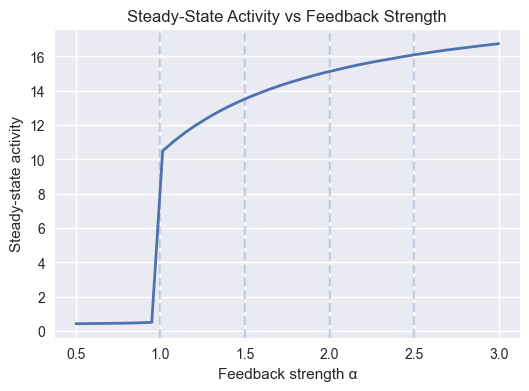

In [11]:
plt.figure(figsize=(6,4))

plt.plot(alpha_scan, steady_states, linewidth=2)

for a in [1.0, 1.5, 2.0, 2.5]:
    plt.axvline(a, linestyle="--", alpha=0.3)

plt.xlabel("Feedback strength α")
plt.ylabel("Steady-state activity")

plt.title("Steady-State Activity vs Feedback Strength")

plt.grid(True)
plt.show()

**Interpretation of Steady-State Activity vs Feedback Strength**

The steady-state activity increases with feedback strength $\alpha$.

At low values of $\alpha$, the system supports only a small activity level. As $\alpha$ increases, the steady-state activity rises sharply and then continues increasing more gradually.

This pattern indicates that stronger feedback supports larger persistent activity levels, while the curve’s shape suggests a threshold-like transition between weakly sustained activity and strongly self-maintained activity.

The vertical dashed lines indicate the specific $\alpha$ values used in the trajectory simulations above.

## Persistence Regime Maps (environmental viability)

A single time-series simulation only shows the behavior of the system for one set of parameters.

To understand under which conditions sustained activity can exist, we construct **persistence regime maps**.

We vary two environmental parameters:

- **Environmental input $I$**: external support for activity
- **Loss rate $\delta$**: degradation or dissipation of activity

For each pair $(I, \delta)$, the system is simulated from a small initial condition and the final state is classified as either:

- **Persistent** if the final activity remains above a small threshold
- **Collapse** if the activity decays toward zero

To examine how internal feedback changes environmental robustness, this analysis is repeated for several values of the feedback parameter \(\alpha\).

In [12]:
I_vals = np.linspace(0, 0.05, 50)
delta_vals = np.linspace(0, 5, 50)

alpha_values = [0.3, 0.8, 2.0]

In [13]:
persistence_maps = []

for a in alpha_values:

    persistence_map = np.zeros((len(I_vals), len(delta_vals)))

    for i, I_val in enumerate(I_vals):
        for j, delta_val in enumerate(delta_vals):

            final_x = final_state(
                x0=0.1,
                alpha=a,
                n=n,
                K=K,
                Kc=Kc,
                delta=delta_val,
                I=I_val,
                t=200
            )

            # protect against solver failures
            if not np.isnan(final_x) and final_x > epsilon:
                persistence_map[i, j] = 1

    persistence_maps.append(persistence_map)


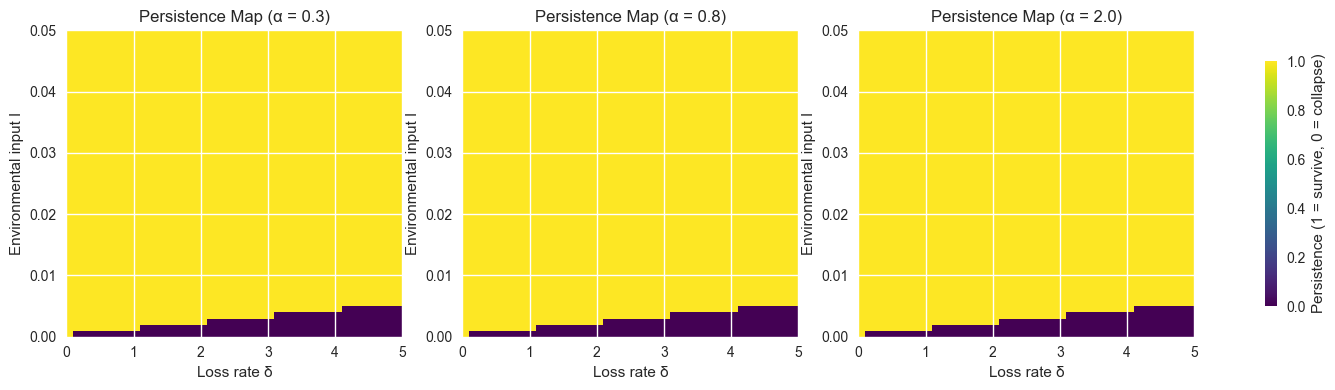

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# create grid for contour plotting
X, Y = np.meshgrid(delta_vals, I_vals)

for idx, (ax, persistence_map) in enumerate(zip(axes, persistence_maps)):

    im = ax.imshow(
        persistence_map,
        extent=[delta_vals[0], delta_vals[-1], I_vals[0], I_vals[-1]],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    ax.set_xlabel("Loss rate δ")
    ax.set_ylabel("Environmental input I")
    ax.set_title(f"Persistence Map (α = {alpha_values[idx]})")

plt.tight_layout()

cbar = fig.colorbar(im, ax=axes, shrink=0.8)
cbar.set_label("Persistence (1 = survive, 0 = collapse)")

plt.show()

**Interpretation of the Persistence Regime Map**

These maps illustrate the environmental conditions under which the system can sustain activity.

Yellow regions correspond to persistent activity $(x^* > \epsilon)$, while dark regions correspond to collapse $(x^* \approx 0)$. The white contour marks the approximate boundary separating these two regimes.

Across all three panels, persistence occurs when environmental input I is sufficiently large relative to the degradation rate \delta. As degradation increases, a larger environmental input is required to maintain activity. This boundary therefore represents the minimum environmental support required for persistence.

Comparing the three panels shows that increasing feedback strength $\alpha$ slightly expands the persistence region. Stronger feedback allows the system to maintain activity under somewhat harsher environmental conditions, although the overall structure of the viability boundary remains similar across feedback regimes.

Overall, these maps demonstrate that sustained activity emerges only within specific regions of parameter space determined by the balance between nonlinear feedback, degradation, and environmental input.

## Three-State Regime Map (Collapse / Bistable / Persistent)

A binary persistence map only tells us whether the system ends in survival or collapse from one initial condition.

However, dynamical systems can also show **bistability**, where the long-term outcome depends on the starting state.

To detect this, we simulate the system from two different initial conditions:

- a **low initial condition** $x_0 = 0.01$
- a **high initial condition** $x_0 = 2.0$

For each environmental condition $(I, \delta)$, the outcomes are classified as:

- **0 = collapse / monostable low**: both initial conditions collapse
- **1 = bistable**: low initial condition collapses, high initial condition persists
- **2 = persistent / monostable high**: both initial conditions persist

This produces a three-state map that reveals whether the system has a true attractor structure with threshold-dependent behavior.

In [15]:
I_vals = np.linspace(0, 0.05, 35)
delta_vals = np.linspace(0, 5, 35)

alpha_values = [0.3, 0.8, 2.0]

In [16]:
three_state_maps = []

for a in alpha_values:

    regime_map = np.zeros((len(I_vals), len(delta_vals)))

    for i, I_val in enumerate(I_vals):
        for j, delta_val in enumerate(delta_vals):

            final_low = final_state(
                x0=0.01,
                alpha=a,
                n=n,
                K=K,
                Kc=Kc,
                delta=delta_val,
                I=I_val,
                t=300
            )

            final_high = final_state(
                x0=2.0,
                alpha=a,
                n=n,
                K=K,
                Kc=Kc,
                delta=delta_val,
                I=I_val,
                t=200
            )

            # guard against solver issues
            if np.isnan(final_low) or np.isnan(final_high):
                regime = 0

            elif final_low <= epsilon and final_high <= epsilon:
                regime = 0  # collapse

            elif final_low <= epsilon and final_high > epsilon:
                regime = 1  # bistable

            else:
                regime = 2  # persistent

            regime_map[i, j] = regime

    three_state_maps.append(regime_map)

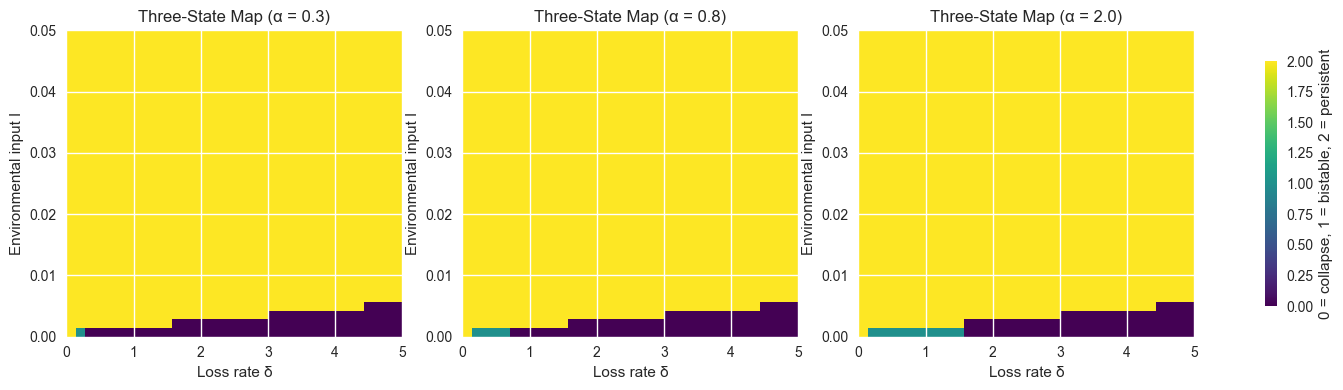

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# mesh for contour boundaries
X, Y = np.meshgrid(delta_vals, I_vals)

for idx, (ax, regime_map) in enumerate(zip(axes, three_state_maps)):

    regime_map = regime_map.astype(int)

    im = ax.imshow(
        regime_map,
        extent=[delta_vals.min(), delta_vals.max(), I_vals.min(), I_vals.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=2
    )

    ax.set_xlabel("Loss rate δ")
    ax.set_ylabel("Environmental input I")
    ax.set_title(f"Three-State Map (α = {alpha_values[idx]})")

plt.tight_layout()

cbar = fig.colorbar(im, ax=axes, shrink=0.8)
cbar.set_label("0 = collapse, 1 = bistable, 2 = persistent")

plt.show()

**Interpretation**

The three-state regime maps classify the long-term dynamical behavior of the system across environmental conditions.

Yellow regions correspond to monostable persistence, where activity converges to a stable active state regardless of initial conditions. Purple regions correspond to collapse, where activity decays to zero.

Green regions indicate bistability, where both collapse and persistence are stable attractors. In this regime the final outcome depends on the initial activity level: sufficiently large initial activity leads to persistence, whereas small initial activity collapses.

Comparing the panels shows that bistability emerges only when feedback strength is sufficiently large. Strong nonlinear feedback allows the system to sustain activity even under very weak environmental input, creating a threshold that separates collapse from persistent activity.

This structure illustrates how nonlinear feedback can generate self-sustaining dynamical states, a key property expected in early metabolic networks.


## Bistability and Attractor Structure

Nonlinear feedback systems can exhibit **multiple stable steady states** under the same environmental conditions.  
This phenomenon is known as **bistability**.

In a bistable system, the dynamics contain:

• a **collapse attractor** where activity decays toward zero  
• a **persistent attractor** where activity stabilizes at a positive level  
• an **unstable equilibrium** between them that acts as a threshold

This unstable point separates the **basins of attraction** of the two stable states.

If the initial activity is **below the threshold**, the system evolves toward collapse.  
If the initial activity is **above the threshold**, the system evolves toward sustained activity.

Conceptually, this threshold represents the **minimum activity level required for a self-sustaining chemical network**.

In the context of origin-of-life models, bistability is important because it suggests that:

• inactive chemistry and active metabolic networks can coexist as alternative dynamical states  
• the transition between them occurs when activity crosses a **critical activation threshold**

To analyze this attractor structure, three complementary approaches are used:

1. **Phase-line analysis**, which reveals the fixed points of the dynamical system and their stability.
2. **Bifurcation analysis**, which shows how the number and position of steady states change as parameters vary.
3. **Basin of attraction analysis**, which determines which initial conditions lead to each attractor.

Together, these analyses help characterize both the **existence** and the **accessibility** of self-sustaining activity in the model.

## Phase-Line Diagram

To better understand the bistable dynamics, we examine the function $dx/dt$ as a function of activity $x$.

Fixed points occur where $dx/dt = 0$.

Stable fixed points correspond to attractors of the system, while unstable fixed points act as thresholds separating different dynamical outcomes.

The phase-line diagram therefore reveals the dynamical structure underlying the basin of attraction.

To illustrate this structure, we evaluate the system at a parameter set that lies within the **bistable regime** identified in the regime maps. In this regime the system possesses multiple steady states, making it possible to visualize the stability structure directly.

Specifically, we use the parameter values $\alpha = 2.0$, $I = 0.001$, and $\delta = 1.2$. Under these conditions the system exhibits three fixed points: a low-activity stable state corresponding to collapse, an intermediate unstable state acting as a threshold, and a high-activity stable state corresponding to persistent activity.

In [ ]:
# environmental parameters (kept fixed)
delta_phase = 1.2
I_phase = 0.001

# feedback strengths to compare
alpha_values = [0.5, 1.2, 2.0]

In [52]:
x_vals = np.linspace(0, 12, 400)

phase_data = {}

for alpha_phase in alpha_values:

    dxdt_vals = []

    for x in x_vals:
        dxdt = model(0, [x], alpha_phase, n, K, Kc, delta_phase, I_phase)[0]
        dxdt_vals.append(dxdt)

    dxdt_vals = np.array(dxdt_vals)

    # detect fixed points automatically
    zero_crossings = np.where(np.diff(np.sign(dxdt_vals)))[0]
    fixed_points = x_vals[zero_crossings]

    phase_data[alpha_phase] = {
        "dxdt": dxdt_vals,
        "fixed_points": fixed_points
    }

    print(f"alpha = {alpha_phase} → approx fixed points:", fixed_points)

alpha = 0.5 → approx fixed points: [0.]
alpha = 1.2 → approx fixed points: [0.]
alpha = 2.0 → approx fixed points: [0.         1.20300752 7.96992481]


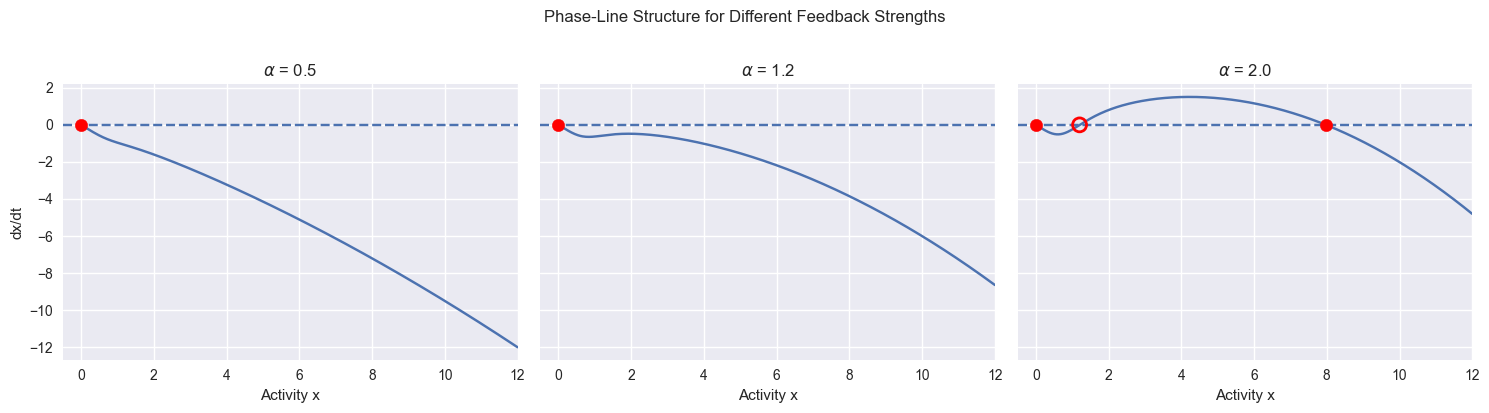

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, alpha_phase in zip(axes, alpha_values):

    dxdt_vals = phase_data[alpha_phase]["dxdt"]
    fixed_points = phase_data[alpha_phase]["fixed_points"]

    ax.plot(x_vals, dxdt_vals)

    ax.axhline(0, linestyle="--")

    # plot fixed points
    for i, fp in enumerate(fixed_points):

        if i % 2 == 0:   # stable
            ax.scatter(fp, 0,
                       color="red",
                       s=80,
                       zorder=5)

        else:            # unstable
            ax.scatter(fp, 0,
                       facecolors="none",
                       edgecolors="red",
                       s=100,
                       linewidth=2,
                       zorder=6)

    ax.set_title(f"$\\alpha$ = {alpha_phase}")
    ax.set_xlabel("Activity x")
    ax.grid(True)
    ax.set_xlim(-0.5, 12)

axes[0].set_ylabel("dx/dt")

plt.suptitle("Phase-Line Structure for Different Feedback Strengths", y=1.02)

plt.tight_layout()
plt.show()

### Interpretation of the Phase-Line Diagrams

The phase-line diagrams illustrate how the dynamical structure of the system changes as the nonlinear feedback strength $ \alpha $ increases.

For low feedback strength ($\alpha = 0.5$), the system has only a single stable fixed point near $x \approx 0$. In this regime activity decays toward collapse because nonlinear amplification is too weak to overcome degradation.

At intermediate feedback ($\alpha = 1.2$), the qualitative structure remains similar: the system still possesses a single stable low-activity state. Although feedback slightly slows the decay of activity, persistence cannot be maintained.

For strong feedback ($\alpha = 2.0$), the phase line develops three fixed points:

$$
x \approx 0, \qquad x \approx 1.2, \qquad x \approx 8.0
$$

The low-activity and high-activity fixed points are stable, while the intermediate point is unstable and acts as a threshold separating collapse from persistent activity. Initial conditions below this threshold evolve toward collapse, while those above it converge toward the persistent attractor.

This transition demonstrates how sufficiently strong nonlinear feedback creates the threshold structure required for bistability and sustained activity.

## Bifurcation Diagram

To better understand how environmental conditions affect the system's behavior, we construct a bifurcation diagram.

A bifurcation diagram shows how the steady-state activity changes as a control parameter varies. In this analysis, we vary the degradation rate $ \delta $, which represents the loss or decay of activity in the system.

Because the system depends on multiple environmental parameters, we fix the environmental input $ I $ and vary only $ \delta $. The value $ I = 0.001 $ is chosen from the bistable region identified in the regime maps, where both collapse and persistence are possible depending on the initial condition.

For each value of $ \delta $, the system is simulated from two different initial conditions (low and high activity). If both converge to the same steady state the system is monostable; if they converge to different steady states the system exhibits bistability.

In [21]:
delta_scan = np.linspace(0, 3, 300)

steady_low = []
steady_high = []

I_bif = 0.001   # use bistable regime

for d in delta_scan:

    final_low = final_state(
        x0=0.01,
        alpha=alpha,
        n=n,
        K=K,
        Kc=Kc,
        delta=d,
        I=I_bif,
        t=600
    )

    final_high = final_state(
        x0=2.0,
        alpha=alpha,
        n=n,
        K=K,
        Kc=Kc,
        delta=d,
        I=I_bif,
        t=600
    )

    steady_low.append(final_low if final_low is not None else np.nan)
    steady_high.append(final_high if final_high is not None else np.nan)

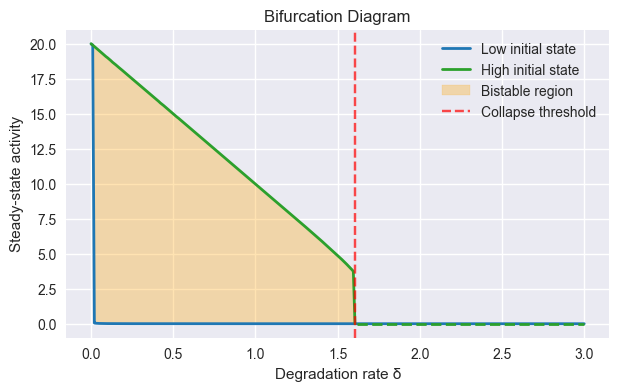

In [22]:
plt.figure(figsize=(7,4))

steady_low = np.array(steady_low)
steady_high = np.array(steady_high)

# detect collapse point
collapse_idx = np.where(steady_high < epsilon)[0]
collapse_delta = delta_scan[collapse_idx[0]] if len(collapse_idx) > 0 else None

# blue branch
plt.plot(delta_scan, steady_low, label="Low initial state", linewidth=2, color="#1f77b4")

# green branch (split into solid and dashed)
if collapse_delta is not None:

    before = delta_scan <= collapse_delta
    after = delta_scan > collapse_delta

    plt.plot(
        delta_scan[before],
        steady_high[before],
        linewidth=2,
        color="#2ca02c",
        label="High initial state"
    )

    # dashed continuation (no legend entry)
    plt.plot(
        delta_scan[after],
        steady_high[after],
        linewidth=2,
        linestyle="--",
        color="#2ca02c"
    )

else:
    plt.plot(delta_scan, steady_high, linewidth=2, color="#2ca02c", label="High initial state")

# bistable region
bistable_mask = np.abs(steady_high - steady_low) > epsilon

plt.fill_between(
    delta_scan,
    steady_low,
    steady_high,
    where=bistable_mask,
    color="orange",
    alpha=0.3,
    label="Bistable region"
)

# collapse threshold
if collapse_delta is not None:
    plt.axvline(
        collapse_delta,
        linestyle="--",
        color="red",
        alpha=0.7,
        label="Collapse threshold"
    )

plt.xlabel("Degradation rate δ")
plt.ylabel("Steady-state activity")
plt.title("Bifurcation Diagram")

plt.grid(True)
plt.legend()

plt.show()

**Interpretation**

The bifurcation diagram shows how the steady-state activity changes as the degradation rate $\delta$ increases.

For small degradation rates, the system converges to a persistent active state regardless of the initial activity level. In this regime the nonlinear feedback dominates degradation, allowing the activity to grow until it approaches the saturation level set by $K_c$. The persistent attractor is therefore the only stable state.

As degradation increases, a bistable region emerges in which two stable attractors coexist: a persistent active state and a collapsed state. The final outcome depends on the initial activity level. Large initial activity leads to persistence, while small initial activity leads to collapse.

For sufficiently large degradation rates, degradation dominates the nonlinear feedback and the persistent state disappears. The system then collapses to zero activity for all initial conditions.

This transition illustrates how nonlinear feedback can generate a threshold separating collapse from self-sustaining activity.

## Basin of Attraction

The three-state regime map identifies regions of parameter space where the system may exhibit bistability.

To examine this threshold behavior more directly, we now compute the **basin of attraction**.

For a fixed set of parameters $(I, \delta, \alpha)$, the system is simulated from many different initial activity levels $x_0$.

Each simulation is classified as either:

- **Persistence** if the final activity remains above a small threshold
- **Collapse** if the activity decays toward zero

The **basin size** is defined as the fraction of initial conditions that lead to persistence.

A large basin indicates robust survival, while a small basin indicates that persistence requires favorable starting conditions.

### Locating a Bistable Environment

To perform basin-of-attraction analysis, we first identify a parameter set that lies inside the bistable region of the three-state regime map.

A point in the bistable region is characterized by:

- collapse when starting from **low initial activity**
- persistence when starting from **high initial activity**

To verify this, we test several candidate points using both low and high initial conditions.

In [23]:
test_points = [
    {"I": 0.001,  "delta": 1.0},
    {"I": 0.001,  "delta": 1.2},
    {"I": 0.0015, "delta": 1.2},
    {"I": 0.0015, "delta": 1.4},
    {"I": 0.002,  "delta": 1.5},
]

for pt in test_points:
    final_low = final_state(
        x0=0.01,
        alpha=2.0,
        n=n,
        K=K,
        Kc=Kc,
        delta=pt["delta"],
        I=pt["I"],
        t=600
    )

    final_high = final_state(
        x0=2.0,
        alpha=2.0,
        n=n,
        K=K,
        Kc=Kc,
        delta=pt["delta"],
        I=pt["I"],
        t=600
    )

    print(
        f"I={pt['I']}, δ={pt['delta']} "
        f"→ low={final_low:.6f}, high={final_high:.6f}"
    )

I=0.001, δ=1.0 → low=0.001000, high=9.988331
I=0.001, δ=1.2 → low=0.000834, high=7.972888
I=0.0015, δ=1.2 → low=0.001251, high=7.972844
I=0.0015, δ=1.4 → low=0.001072, high=5.935142
I=0.002, δ=1.5 → low=0.001334, high=4.873748


### Interpretation of Candidate Bistable Points

To locate a suitable environment for basin-of-attraction analysis, several candidate parameter sets were tested using both low and high initial activity levels.

The classification of the final state is based on a small threshold value ε, defined earlier in the parameters section:

$ε = 1 × 10⁻³$

This threshold is used to distinguish between collapse and persistence:

- If the final activity $x_{final} ≤ ε$, the system is classified as **collapse**
- If $x_{final} > ε$, the system is classified as **persistence**

The threshold is necessary because the numerical solver rarely produces an exact zero value. Instead, collapse typically appears as very small residual activity values close to zero.

Among the tested points, the parameter set
$$
I = 0.001 ,
δ = 1.2
$$

shows clear bistable behavior:

- the system collapses when starting from low activity
- the system persists when starting from high activity

Other tested points were not selected for basin analysis for the following reasons:

- Some points produced persistence for both initial conditions, indicating a **monostable persistent regime**.
- Other points produced final activity values very close to the ε threshold for the low initial condition. In such cases, the classification becomes sensitive to the exact value of ε and may not reliably indicate true bistability.
- A few points showed collapse for both initial conditions, corresponding to the **monostable collapse regime**.

The selected point therefore provides the clearest example of bistability, where the final system state depends strongly on the initial activity level.

This makes it an appropriate environment for analyzing the **basin of attraction** separating collapse and persistence.

### Basin of Attraction at a Bistable Point

Having identified a representative bistable environment, we now vary the initial activity level $x_0$ systematically.

This reveals the basin boundary separating collapse from persistence.

In [24]:
alpha_basin = 2.0
I_basin = 0.001
delta_basin = 1.2

In [25]:
initial_conditions = np.linspace(0, 2, 120)

basin_results = []

for x0_test in initial_conditions:

    final_x = final_state(
        x0=x0_test,
        alpha=alpha_basin,
        n=n,
        K=K,
        Kc=Kc,
        delta=delta_basin,
        I=I_basin,
        t=600
    )

    if np.isnan(final_x):
        basin_results.append(0)
    elif final_x > epsilon:
        basin_results.append(1)
    else:
        basin_results.append(0)

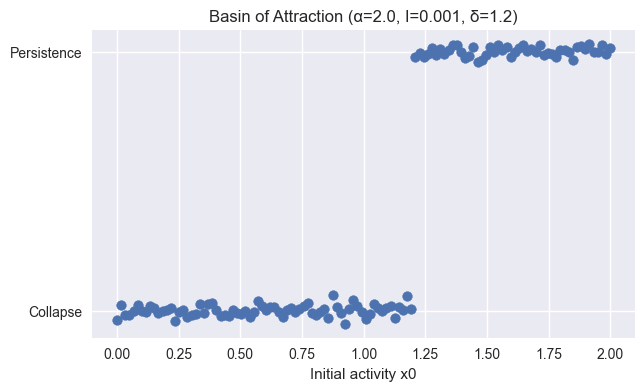

In [26]:
plt.figure(figsize=(7,4))

jitter = np.random.normal(0, 0.02, len(basin_results))

plt.scatter(initial_conditions, np.array(basin_results) + jitter)

plt.xlabel("Initial activity x0")
plt.yticks([0,1], ["Collapse", "Persistence"])
plt.title(f"Basin of Attraction (α={alpha_basin}, I={I_basin}, δ={delta_basin})")

plt.grid(True)
plt.show()

In [27]:
basin_size = np.mean(basin_results)
print("Basin size:", basin_size)

Basin size: 0.4


**Interpretation of the Basin of Attraction**

At this parameter set, the system exhibits a clear threshold in initial activity.

Small initial activity levels collapse to the low-activity state, whereas sufficiently large initial activity levels converge to the persistent attractor.

This indicates that the system is bistable: both collapse and persistence are stable outcomes, and the final state depends on whether the initial condition lies below or above the basin boundary.

The basin size quantifies how much of the tested initial-condition space leads to persistence.

### Basin Robustness Landscape
To evaluate how robust the persistent attractor is across environmental conditions, the basin of attraction was computed across a grid of degradation rates (δ) and environmental input levels (I).

For each parameter pair, multiple initial activity values were simulated. The basin size is defined as the fraction of initial conditions that converge to the persistent attractor.

Values close to 1 indicate that persistence is highly robust, while values near 0 indicate that most initial conditions lead to collapse.

This produces a robustness landscape showing how environmental support and degradation jointly determine the stability of the system.

In [46]:
# parameter ranges
delta_vals = np.linspace(0, 5, 20)
I_vals = np.linspace(0, 0.05, 20)

# basin_matrix[row = I, column = delta]
basin_matrix = np.zeros((len(I_vals), len(delta_vals)))

# initial conditions to test
initial_conditions = np.linspace(0, 2, 20)

for i, I_test in enumerate(I_vals):
    for j, delta_test in enumerate(delta_vals):

        basin_results = []

        for x0_test in initial_conditions:

            final_x = final_state(
                x0=x0_test,
                alpha=alpha,
                n=n,
                K=K,
                Kc=Kc,
                delta=delta_test,
                I=I_test
            )

            if final_x is None or not np.isfinite(final_x):
                basin_results.append(0)

            elif final_x > epsilon:
                basin_results.append(1)

            else:
                basin_results.append(0)

        basin_matrix[i, j] = np.mean(basin_results)

In [49]:
import plotly.graph_objects as go

delta_grid, I_grid = np.meshgrid(delta_vals, I_vals)

fig = go.Figure(
    data=[
        go.Surface(
            x=delta_grid,
            y=I_grid,
            z=basin_matrix,
            colorscale="Viridis",
            colorbar=dict(title=dict(text="Basin size")),
            contours=dict(
                z=dict(
                    show=True,
                    usecolormap=True,
                    highlightcolor="white",
                    project_z=True
                )
            )
        )
    ]
)

fig.update_layout(
    title="Basin Robustness Landscape",

    scene=dict(
        xaxis=dict(title="Loss rate δ"),
        yaxis=dict(title="Environmental input I"),
        zaxis=dict(title="Basin size", range=[0,1]),

        camera=dict(
            eye=dict(x=1.4, y=-1.8, z=1.2)
        )
    ),

    width=800,
    height=600
)

fig.show()

**Interpretation of the Basin Robustness Landscape**

The surface illustrates how environmental parameters influence the robustness of the persistent attractor.

For low degradation rates and sufficient environmental input, the basin size approaches one. In this region nearly all tested initial conditions converge to sustained activity, indicating that the persistent state is highly robust to perturbations.

As the degradation rate increases or environmental input decreases, the basin size rapidly shrinks. This indicates that progressively fewer initial conditions lead to sustained activity, and collapse becomes the dominant dynamical outcome.

The steep boundary separating these regimes marks the environmental threshold beyond which sustained activity is no longer robust. Near this boundary the system becomes highly sensitive to initial conditions, reflecting a critical transition between persistence and collapse.

## Recovery from Perturbations

To test the resilience of the attractor, we apply perturbations of different strengths to the steady state.

For each perturbation level, the activity is suddenly reduced by a fraction of its steady-state value.

The system is then simulated again to determine whether it returns to the attractor or collapses.

This allows us to identify how large a disturbance the system can tolerate while still maintaining persistence.

In [30]:
t_base, x_base = simulate(x0, alpha, n, K, Kc, delta, I)

x_steady = x_base[-1]

print("Steady state:", x_steady)

Steady state: 15.12890267869433


In [31]:
perturbations = [0.1, 0.3, 0.5, 0.7, 0.9]

In [32]:
recovery_results = []

for p in perturbations:

    x_perturbed = (1 - p) * x_steady

    t_rec, x_rec = simulate(
        x_perturbed,
        alpha,
        n,
        K,
        Kc,
        delta,
        I,
        t=200
    )

    if t_rec is None:
        continue

    recovery_results.append({
    "p": p,
    "t": t_rec,
    "x": x_rec
    })

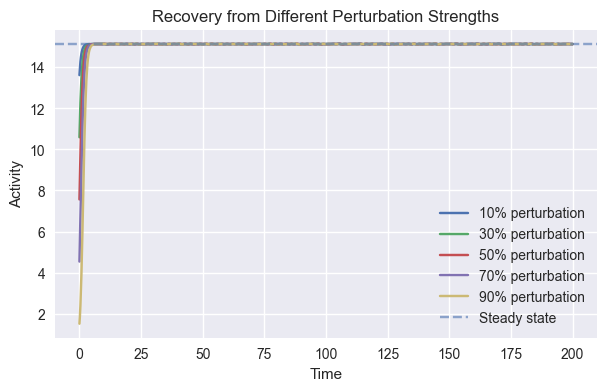

In [33]:
plt.figure(figsize=(7,4))

for r in recovery_results:

    p = r["p"]
    t_rec = r["t"]
    x_rec = r["x"]

    plt.plot(
        t_rec,
        x_rec,
        label=f"{int(p*100)}% perturbation"
    )

plt.axhline(x_steady, linestyle="--", alpha=0.6, label="Steady state")

plt.xlabel("Time")
plt.ylabel("Activity")

plt.title("Recovery from Different Perturbation Strengths")

plt.legend()
plt.grid(True)

plt.show()

**Interpretation**

To evaluate the robustness of the persistent attractor, perturbations of varying strength were applied to the steady-state activity level. After each perturbation, the system dynamics were simulated to observe whether recovery occurred.

As shown in the figure, the system returns to the persistent steady state across all tested perturbation strengths, including reductions of up to 90% of the activity level. This indicates that the persistent attractor possesses a large basin of attraction and exhibits strong resilience to disturbances.

Such robustness is characteristic of nonlinear systems with stable attractors, where recovery dynamics drive the system back toward the steady state following perturbations.

In [34]:
collapse_threshold = None

for p in perturbations:

    x_perturbed = (1 - p) * x_steady

    final_x = final_state(
        x_perturbed,
        alpha,
        n,
        K,
        Kc,
        delta,
        I
    )

    if np.isnan(final_x) or final_x <= epsilon:
        collapse_threshold = p
        break

print("Collapse threshold perturbation:", collapse_threshold)

Collapse threshold perturbation: None


## Chirality Effects

The previous sections examined persistence, bistability, and basin structure in a single-variable dynamical model.

To explore chirality more directly, we extend the system to two coupled activity variables representing left- and right-handed molecular species:

- $L(t)$ — activity of the left-handed species  
- $R(t)$ — activity of the right-handed species  

This extension allows us to investigate whether nonlinear chemical networks can spontaneously break symmetry and favor one molecular handedness.

Two related questions are addressed:

1. **Chiral dynamics:** how the activities of the two species evolve over time.
2. **Symmetry breaking:** whether the system converges to a racemic state ($L = R$) or a homochiral state where one species dominates.

The degree of asymmetry is quantified using the **enantiomeric excess**

$$
ee = \frac{L - R}{L + R}
$$

which measures the imbalance between the two enantiomers.

### Chirality Symmetry Breaking

To study the emergence of chirality, we extend the model to include two interacting species representing left-handed and right-handed molecular forms.

The dynamics of the system are described by the coupled differential equations

$$
\frac{dL}{dt} =
\alpha \frac{L^n}{K^n + L^n}\left(1-\frac{L+R}{K_c}\right)
- \delta L
+ I
- \gamma R
$$

$$
\frac{dR}{dt} =
\alpha \frac{R^n}{K^n + R^n}\left(1-\frac{L+R}{K_c}\right)
- \delta R
+ I
- \gamma L
$$

The first three terms represent nonlinear amplification, environmental input, and degradation as in the single-variable model.

The additional term proportional to $\gamma$ introduces **cross-inhibition between the two enantiomers**, representing competition between the two chiral forms.

Because the equations are symmetric under the exchange $L \leftrightarrow R$, the racemic state $L = R$ always exists as a possible equilibrium. Whether this symmetric state remains stable depends on the strength of the cross-inhibition parameter $\gamma$.

In [35]:
def chiral_system(t, y, alpha, n, K, Kc, delta, I, coupling):

    L, R = y

    # prevent negative numerical values
    L = max(L, 0)
    R = max(R, 0)

    # Hill nonlinear feedback
    hill_L = (L**n) / (K**n + L**n + 1e-9)
    hill_R = (R**n) / (K**n + R**n + 1e-9)

    # shared resource limitation
    resource = 1 - (L + R) / Kc

    # nonlinear growth
    growth_L = alpha * L * hill_L * resource
    growth_R = alpha * R * hill_R * resource

    # cross inhibition (Frank-type antagonism)
    inhibition = coupling * L * R

    dLdt = growth_L - delta * L + I - inhibition
    dRdt = growth_R - delta * R + I - inhibition

    return [dLdt, dRdt]

**Interpretation**

With this dynamical system defined, we can now simulate the interaction between the two enantiomers and observe how their activities evolve over time.

In particular, we will examine whether small asymmetries grow or decay, revealing whether the system favors racemic stability or homochiral dominance.

### Chiral Dynamics

We now simulate the time evolution of the two enantiomers starting from nearly symmetric initial conditions.

Both species follow identical nonlinear growth dynamics but interact through mutual inhibition. Small differences in the initial conditions may either decay or become amplified depending on the balance between nonlinear amplification and cross-inhibition.

By plotting $L(t)$ and $R(t)$ we can observe whether the system converges toward a racemic equilibrium or whether one enantiomer begins to dominate.

In [36]:
# environment parameters for the chirality experiment
delta_chiral = 0.3
I_chiral = 0.05
coupling = 0.1

In [37]:
# small asymmetry in initial conditions
y0 = [1.01, 1.0]

t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)

sol_dyn = solve_ivp(
    chiral_system,
    t_span,
    y0,
    args=(alpha, n, K, Kc, delta_chiral, I_chiral, coupling),
    t_eval=t_eval,
    method="RK45"
)

if not sol_dyn.success:
    print(sol_dyn.message)

t = sol_dyn.t
L = sol_dyn.y[0]
R = sol_dyn.y[1]

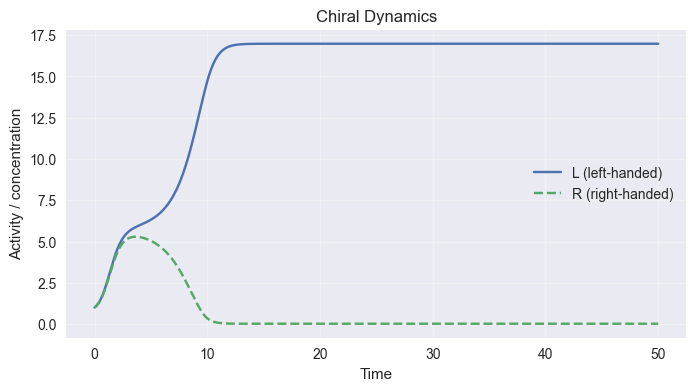

In [38]:
plt.figure(figsize=(8,4))

plt.plot(t, L, label="L (left-handed)")
plt.plot(t, R, "--", label="R (right-handed)")

plt.xlabel("Time")
plt.ylabel("Activity / concentration")
plt.title("Chiral Dynamics")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

**Interpretation**

Both enantiomers initially grow due to environmental input and nonlinear feedback. At early times the two species increase together, indicating that the chemical network supports stable activity for both forms.

As concentrations rise, mutual inhibition between the two species becomes stronger. Because the initial conditions contain a small asymmetry, this competition gradually amplifies the difference between the enantiomers.

In this simulation the left-handed species eventually outcompetes the right-handed one. The activity of the right-handed species first rises slightly but then collapses toward zero, while the left-handed species stabilizes at a high steady-state level.

The system therefore converges to a **homochiral state** in which a single enantiomer dominates the network. This behavior demonstrates how nonlinear feedback and mutual inhibition can amplify tiny initial asymmetries into complete symmetry breaking.

### Phase Portrait of the Chiral System

To better understand the dynamical behavior of the two-species system, we examine its **phase portrait** in the $(L,R)$ state space.

Instead of plotting activity versus time, this representation shows the direction of change of the system at different points in the $(L,R)$ plane.

The arrows represent the vector field defined by the coupled dynamical equations, while trajectories illustrate how the system evolves from different initial conditions.

This visualization reveals whether the racemic state $L = R$ acts as a stable attractor and how nearby states evolve toward equilibrium.

In [39]:
# ---- compute vector field for phase portrait ----

L_vals = np.linspace(0,2,20)
R_vals = np.linspace(0,2,20)

L_grid, R_grid = np.meshgrid(L_vals, R_vals)

dL = np.zeros_like(L_grid)
dR = np.zeros_like(R_grid)

for i in range(L_grid.shape[0]):
    for j in range(L_grid.shape[1]):

        L = L_grid[i,j]
        R = R_grid[i,j]

        dL_val, dR_val = chiral_system(
            0,
            [L, R],
            alpha,
            n,
            K,
            Kc,
            delta_chiral,
            I_chiral,
            coupling
        )

        dL[i,j] = dL_val
        dR[i,j] = dR_val


# normalize vectors (better visualization)
magnitude = np.sqrt(dL**2 + dR**2) + 1e-9
dL = dL / magnitude
dR = dR / magnitude


# compute equilibrium
sol = solve_ivp(
    chiral_system,
    (0,400),
    [1,1],
    args=(alpha,n,K,Kc,delta_chiral,I_chiral,coupling)
)

L_star = sol.y[0,-1]
R_star = sol.y[1,-1]

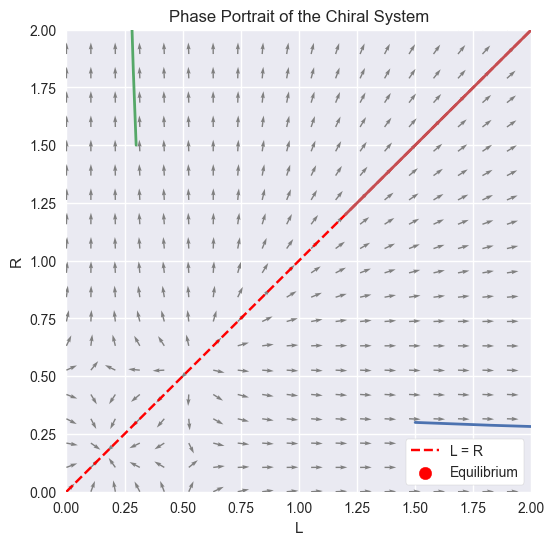

In [40]:
plt.figure(figsize=(6,6))

# vector field
plt.quiver(
    L_grid,
    R_grid,
    dL,
    dR,
    angles='xy',
    scale_units='xy',
    scale=20,
    color="gray"
)

# symmetry line
plt.plot([0,2],[0,2],'r--',label='L = R')

# equilibrium point
plt.scatter(L_star, R_star, color="red", s=80, label="Equilibrium")

# trajectories
for IC in [[1.5,0.3],[0.3,1.5],[1.2,1.2]]:
    sol = solve_ivp(
        chiral_system,
        (0,50),
        IC,
        args=(alpha,n,K,Kc,delta_chiral,I_chiral,coupling),
        t_eval=np.linspace(0,50,300)
    )
    plt.plot(sol.y[0], sol.y[1], linewidth=2)

plt.xlim(0,2)
plt.ylim(0,2)

plt.xlabel("L")
plt.ylabel("R")

plt.legend(frameon=True, facecolor="white", framealpha=1)

plt.title("Phase Portrait of the Chiral System")

plt.show()

**Interpretation of the Phase Portrait**

The phase portrait shows the dynamics of the two chiral species \(L\) and \(R\) in the \((L,R)\) state space. The arrows represent the vector field \((dL/dt, dR/dt)\), indicating how the system evolves from different initial concentrations.

The dashed red line corresponds to the symmetry axis \(L = R\), which represents racemic states where both enantiomers are present in equal amounts. Points along this line correspond to perfectly symmetric configurations.

The vector field reveals that this symmetric configuration is not globally stable under the chosen parameters. Small deviations from the symmetry line tend to grow as the system evolves. As trajectories move through the phase space, the dynamics drive the system toward states where one species dominates while the other is suppressed.

This behavior reflects the combined effects of nonlinear amplification and mutual inhibition between the two species. When the concentrations increase, competitive interactions amplify small initial asymmetries, pushing the system away from the racemic line and toward a **homochiral state** in which one enantiomer becomes dominant.


### Quantifying Chirality: Enantiomeric Excess

To quantify how chirality develops over time, we track the **enantiomeric excess**

$$
ee(t) = \frac{L(t) - R(t)}{L(t) + R(t)}
$$

This quantity measures the instantaneous imbalance between the two chiral species.

• $ee = 0$ corresponds to a racemic mixture  
• $ee > 0$ indicates left-handed dominance  
• $ee < 0$ indicates right-handed dominance  

By plotting $ee(t)$ we can determine whether small initial asymmetries are amplified or suppressed by the nonlinear dynamics.

In [41]:
t_series = sol_dyn.t
L_series = sol_dyn.y[0]
R_series = sol_dyn.y[1]

ee = (L_series - R_series) / (L_series + R_series + 1e-9)

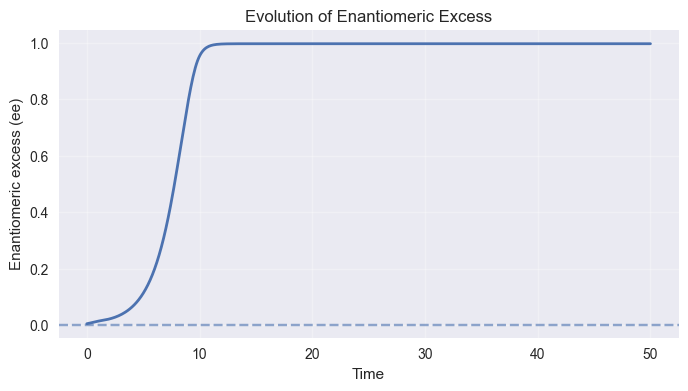

In [42]:
plt.figure(figsize=(8,4))

plt.plot(t_series, ee, linewidth=2)

plt.axhline(0, linestyle="--", alpha=0.6)

plt.xlabel("Time")
plt.ylabel("Enantiomeric excess (ee)")
plt.title("Evolution of Enantiomeric Excess")

plt.grid(alpha=0.3)

plt.show()

In [43]:
print("y0 used:", y0)
print("alpha =", alpha)
print("delta =", delta)
print("I =", I)
print("coupling =", coupling)
print("Final L =", sol.y[0, -1])
print("Final R =", sol.y[1, -1])

y0 used: [1.01, 1.0]
alpha = 2.0
delta = 0.5
I = 0.2
coupling = 0.1
Final L = 5.678995744885472
Final R = 5.678995744885472


**Interpretation**

The enantiomeric excess remains close to zero throughout the simulation, indicating that the small initial asymmetry between the two chiral species is not amplified by the dynamics.

Instead, the system relaxes toward a symmetric racemic state in which \(L(t)\) and \(R(t)\) converge to the same steady value. This behavior indicates that the racemic equilibrium is dynamically stable under the chosen parameter values.

In other words, the current parameter regime suppresses spontaneous symmetry breaking rather than promoting homochirality.

However, the stability of this symmetric equilibrium depends on the strength of mutual inhibition between the two species. To investigate whether other dynamical regimes exist, we next vary the coupling parameter and examine how the final enantiomeric excess changes across parameter space.

### Final Enantiomeric Excess Across Parameters

The previous simulations illustrate the time evolution of chirality for a fixed parameter set. However, the stability of the racemic state depends strongly on the strength of interaction between the two species.

To explore this dependence, we compute the **final enantiomeric excess** across a range of values of the cross-inhibition parameter $\gamma$.

For each value of the coupling strength, the system is simulated until it reaches steady state. The final enantiomeric excess is then measured to determine whether the system converges to a racemic configuration or to a homochiral state dominated by one enantiomer.

This analysis reveals how the balance between nonlinear amplification and cross-inhibition controls the emergence of homochirality.

In [44]:
coupling_vals = np.linspace(0, 1, 50)

ee_final = []

for coupling_val in coupling_vals:

    y0 = [1.01, 1.0]   # small initial asymmetry

    sol = solve_ivp(
        chiral_system,
        (0, 400),
        y0,
        args=(alpha, n, K, Kc, delta_chiral, I_chiral, coupling_val),
        t_eval=np.linspace(0,400,1000),
        method="RK45"
    )

    L_final = sol.y[0, -1]
    R_final = sol.y[1, -1]

    ee = (L_final - R_final) / (L_final + R_final + 1e-9)

    ee_final.append(abs(ee))

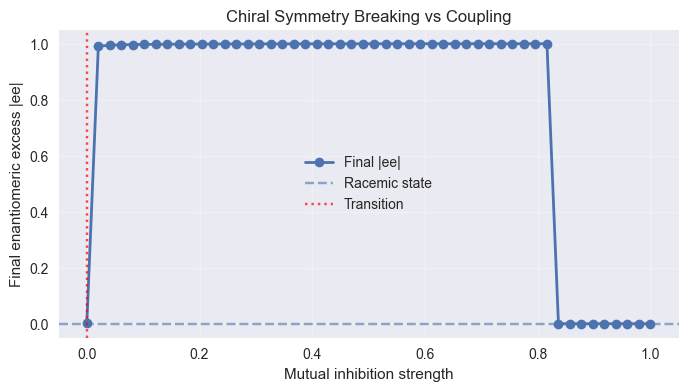

In [45]:
plt.figure(figsize=(8,4))

plt.plot(coupling_vals, ee_final, marker='o', linewidth=2, label="Final |ee|")

plt.axhline(0, linestyle="--", alpha=0.6, label="Racemic state")

# approximate symmetry-breaking transition
drops = np.where(np.array(ee_final) < 0.5 * np.max(ee_final))[0]

if len(drops) > 0:
    plt.axvline(
        coupling_vals[drops[0]],
        linestyle=":",
        alpha=0.7,
        color="red",
        label="Transition"
    )

plt.xlabel("Mutual inhibition strength")
plt.ylabel("Final enantiomeric excess |ee|")
plt.title("Chiral Symmetry Breaking vs Coupling")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

**Interpretation**

The results reveal three distinct dynamical regimes controlled by the strength of mutual inhibition. The dotted vertical line marks the approximate transition between racemic and homochiral regimes.

For very weak coupling, the interaction between the two enantiomers is too small to amplify initial asymmetries, and the system remains close to a racemic state with \(ee \approx 0\).

As the inhibition strength increases, a regime appears in which nonlinear feedback amplifies small differences between the two species. In this intermediate region the system evolves toward a homochiral state, producing large values of \(|ee|\) close to 1.

For very strong inhibition, however, both species strongly suppress each other, which stabilizes the symmetric racemic configuration once again.

These results show that chiral symmetry breaking occurs only within a specific window of interaction strengths where nonlinear amplification dominates over symmetric inhibition.

## Possible Extension: Resource-Coupled Persistence

The present model assumes a constant environmental input \(I\), which represents continuous external support for activity. A natural extension would be to replace this constant input with a dynamical resource variable.

In such a model, the persistence of activity would depend not only on autocatalytic amplification and degradation, but also on the balance between resource replenishment and resource consumption.

This would make the framework more realistic for prebiotic or protocell-like systems, where self-maintaining activity must be sustained by finite environmental resources rather than an unlimited constant input.

The current notebook therefore provides a minimal attractor-based model of persistence, while a resource-coupled version could be explored in future work as a more mechanistic extension.